# Évaluation CL — HDC (D=1024) — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Modèle** | HDC Hyperdimensional Computing (D=1024, 2 048 prototypes) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Expérience** | exp_017 — voir experiments/exp_017_hdc_monitoring_by_location/config_snapshot.yaml |
| **Sprint** | 7 — S7-09 |

> **Modèle supervisé non-neuronal** : accumulation additive d'hypervecteurs binarisés (INT8).
> Aucun gradient, pas de momentum — conforme MCU.
> Inférence : argmax de la similarité cosinus (via POPCOUNT/XOR sur MCU).
> RAM ≈ 14.2 Ko @ FP32 (prototypes_acc INT32 + prototypes_bin INT8 + buffer encodage).
> **Note by_location** : contrairement à by_equipment, on observe AF=0.0274 (pas 0.0) — la
> frontière discriminative shift entre locations même sans écraser les prototypes additifs.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_location/hdc.ipynb \
    --output /tmp/hdc_location_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import fit_pca2d, plot_feature_space_2d

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_017_hdc_monitoring_by_location/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/hdc/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"
CONFIG_PATH     = REPO_ROOT / "configs/hdc_config.yaml"

# --- Constantes ---
TASK_NAMES     = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_NAME     = "HDC"
DATA_AVAILABLE = CSV_PATH.exists() and CONFIG_PATH.exists()

print(f"REPO_ROOT         : {REPO_ROOT}")
print(f"EXP_DIR           : {EXP_DIR}")
print(f"FIGURES_DIR       : {FIGURES_DIR}")
print(f"CSV disponible    : {CSV_PATH.exists()}")
print(f"Config disponible : {CONFIG_PATH.exists()}")
print(f"Date exécution    : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **Ressources absentes** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques)."
    ))

REPO_ROOT         : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR           : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_017_hdc_monitoring_by_location/results
FIGURES_DIR       : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location
CSV disponible    : True
Config disponible : True
Date exécution    : 2026-04-21 13:17


In [2]:
# Section 2 — Chargement des résultats exp_017
# HDC metrics.json : structure nested sous "cl_metrics"

metrics_path    = EXP_DIR / "metrics.json"
acc_matrix_path = EXP_DIR / "acc_matrix_hdc.npy"

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

cl = metrics["cl_metrics"]

# Reconstruire la matrice acc numpy (remplacement null → NaN) — 5×5 pour by_location
acc_matrix_json = np.array(
    [[v if v is not None else np.nan for v in row] for row in cl["acc_matrix"]],
    dtype=float,
)

aa       = cl["aa"]
af       = cl["af"]
bwt      = cl["bwt"]
ram_b    = cl["ram_peak_bytes"]
lat      = cl["inference_latency_ms"]
n_params = cl.get("n_params", 2048)
ram_int8 = cl.get("estimated_ram_int8_bytes", None)
within_budget = ram_b <= 65536

print("=" * 55)
print(f"  Modèle         : HDC (D={cl.get('n_params', 2048) // 2}, {n_params} prototypes)")
print(f"  AA             = {aa:.4f}")
print(f"  AF             = {af:.4f}")
print(f"  BWT            = {bwt:+.4f}")
print(f"  Forgetting/tâche: {[round(v, 4) for v in cl.get('forgetting_per_task', [])]}")
print(f"  RAM peak       = {ram_b} B ({ram_b/1024:.2f} Ko @ FP32)")
if ram_int8:
    print(f"  RAM INT8       = {ram_int8} B ({ram_int8/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_params       = {n_params}")
print(f"  Budget 64 Ko   : {within_budget}")
print("=" * 55)
print(f"\nMatrice acc ({acc_matrix_json.shape[0]}×{acc_matrix_json.shape[1]}) :")
print(acc_matrix_json)

  Modèle         : HDC (D=1024, 2048 prototypes)
  AA             = 0.8563
  AF             = 0.0274
  BWT            = -0.0274
  Forgetting/tâche: [0.0383, 0.0225, 0.0194, 0.0294]
  RAM peak       = 14504 B (14.16 Ko @ FP32)
  RAM INT8       = 6152 B (6.01 Ko)
  Latence        = 0.05008 ms
  n_params       = 2048
  Budget 64 Ko   : True

Matrice acc (5×5) :
[[0.89456869        nan        nan        nan        nan]
 [0.87539936 0.8392283         nan        nan        nan]
 [0.87220447 0.83279743 0.91935484        nan        nan]
 [0.87539936 0.83601286 0.91935484 0.86601307        nan]
 [0.85623003 0.81672026 0.9        0.83660131 0.87205387]]


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location/acc_matrix.png


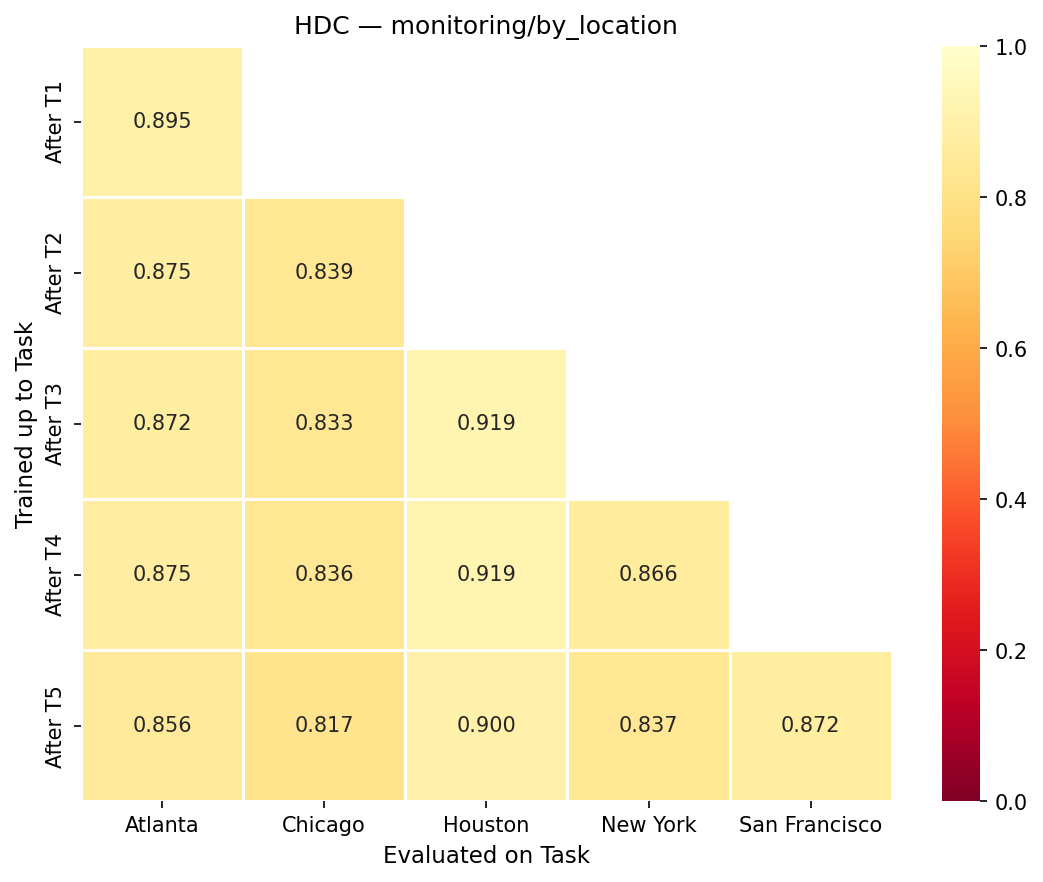

In [3]:
# Section 3 — Matrice d'accuracy (heatmap)
# HDC by_location : AF ≈ 0.027 — la frontière discriminative shift entre locations
# Matrice 5×5 pour les 5 locations

fig = plot_accuracy_matrix(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_location",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location/forgetting_curve.png


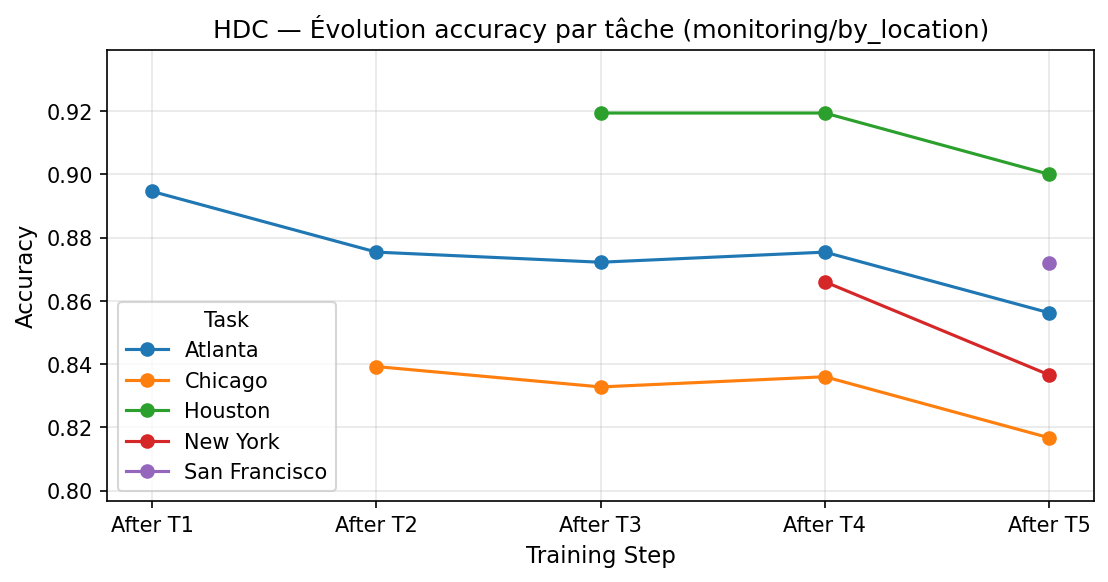

In [4]:
# Section 4 — Courbe d'oubli par tâche
# HDC by_location : AF ≈ 0.0274 — léger oubli dû au shift de distribution géographique.
# Les prototypes additifs ne sont pas écrasés, mais leur séparabilité peut se dégrader
# lorsque de nouvelles observations glissent la frontière de décision dans l'hyperespace.
# 5 courbes correspondant aux 5 locations

fig = plot_forgetting_curve(
    acc_matrix_json,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_location)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

In [5]:
# Section 5 — Rejeu du scénario CL (collecte preds_dict + proba_dict)
# HDC : accumulation des hypervecteurs dans prototypes_acc → binarisation → inférence par similarité cosinus
# Sur 5 locations : Atlanta → Chicago → Houston → New York → San Francisco
# Pour les courbes ROC, on reconstruit un score continu = (sim[1] - sim[0]) / (2*D) + 0.5

preds_dict  = {}
proba_dict  = {}
X_tests_raw = []
y_tests_raw = []

def hdc_scores(model, X):
    '''Scores continus de classe 1 (faulty) dans [0, 1], exploitant les similarités cosinus.'''
    from src.models.hdc.hdc_classifier import encode_observation
    scores = np.zeros(len(X), dtype=np.float32)
    for idx, sample in enumerate(X):
        H_obs = encode_observation(
            sample, model.H_level, model.H_pos, model.feature_bounds, model.n_levels, model.D,
        )
        sims = model.prototypes_bin.astype(np.float32) @ H_obs.astype(np.float32)
        # sim[1] - sim[0] ∈ [-D, D] → normalisation dans [0, 1]
        scores[idx] = (sims[1] - sims[0]) / (2.0 * model.D) + 0.5
    return scores

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders_by_location
    from src.models.hdc.hdc_classifier import HDCClassifier
    from src.utils.reproducibility import set_seed

    set_seed(42)

    # Charger la config HDC
    config = yaml.safe_load(CONFIG_PATH.read_text())
    config["data"]["csv_path"] = str(CSV_PATH)
    config["data"]["normalizer_path"] = str(NORMALIZER_PATH)

    tasks = get_cl_dataloaders_by_location(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=256,
        seed=42,
        location_order=TASK_NAMES,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tests_raw.append(X_v)
        y_tests_raw.append(y_v)

    # Instancier HDCClassifier
    model = HDCClassifier(config)

    for i, task in enumerate(tasks):
        domain = task.get("domain", f"Tâche {task['task_id']}")
        print(f"\n--- Tâche {i + 1}/{len(tasks)} : {domain} ---")

        # Accumulation des hypervecteurs (pas de gradient, 1 passe)
        X_train = np.concatenate([b[0].numpy() for b in task["train_loader"]])
        y_train = np.concatenate([b[1].numpy().flatten() for b in task["train_loader"]]).astype(np.int64)
        err = model.update(X_train, y_train)
        model.on_task_end(task["task_id"], task["train_loader"])
        print(f"  Erreur train : {err:.4f}  (N={len(y_train)})")

        # Évaluation sur toutes les tâches vues jusqu'à i
        for j in range(i + 1):
            y_pred = model.predict(X_tests_raw[j]).astype(float)
            scores = hdc_scores(model, X_tests_raw[j])
            preds_dict[(i, j)] = (y_tests_raw[j], y_pred)
            proba_dict[(i, j)] = scores
            acc = (y_tests_raw[j] == y_pred).mean()
            print(f"  preds_dict[({i},{j})] → N={len(y_tests_raw[j])}, acc={acc:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — preds_dict synthétique depuis acc_matrix."))

    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    n_tasks = acc_matrix_json.shape[0]
    for i in range(n_tasks):
        for j in range(i + 1):
            noise = rng.normal(0, 0.15, N_SYNTH)
            probas_synth = np.where(y_synth == 1, 0.60 + noise, 0.40 + noise).clip(0, 1)
            y_pred_synth = (probas_synth >= 0.5).astype(float)
            preds_dict[(i, j)] = (y_synth.copy(), y_pred_synth)
            proba_dict[(i, j)] = probas_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/5 : Atlanta ---
  Erreur train : 0.4500  (N=1251)
  preds_dict[(0,0)] → N=313, acc=0.5016

--- Tâche 2/5 : Chicago ---
  Erreur train : 0.4171  (N=1242)
  preds_dict[(1,0)] → N=313, acc=0.5942
  preds_dict[(1,1)] → N=311, acc=0.6045

--- Tâche 3/5 : Houston ---
  Erreur train : 0.4087  (N=1238)
  preds_dict[(2,0)] → N=313, acc=0.6038
  preds_dict[(2,1)] → N=311, acc=0.5981
  preds_dict[(2,2)] → N=310, acc=0.5645

--- Tâche 4/5 : New York ---
  Erreur train : 0.4689  (N=1220)
  preds_dict[(3,0)] → N=313, acc=0.5847
  preds_dict[(3,1)] → N=311, acc=0.5177
  preds_dict[(3,2)] → N=310, acc=0.5452
  preds_dict[(3,3)] → N=306, acc=0.5065

--- Tâche 5/5 : San Francisco ---
  Erreur train : 0.4062  (N=1184)
  preds_dict[(4,0)] → N=313, acc=0.6358
  preds_dict[(4,1)] → N=311, acc=0.5498
  preds_dict[(4,2)] → N=310, acc=0.5677
  preds_dict[(4,3)] → N=306, acc=0.5621
  preds_dict[(4,4)] → N=297, acc=0.6364

Scénario CL rejoué — 15 évaluations collect

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location/confusion_matrix_grid.png


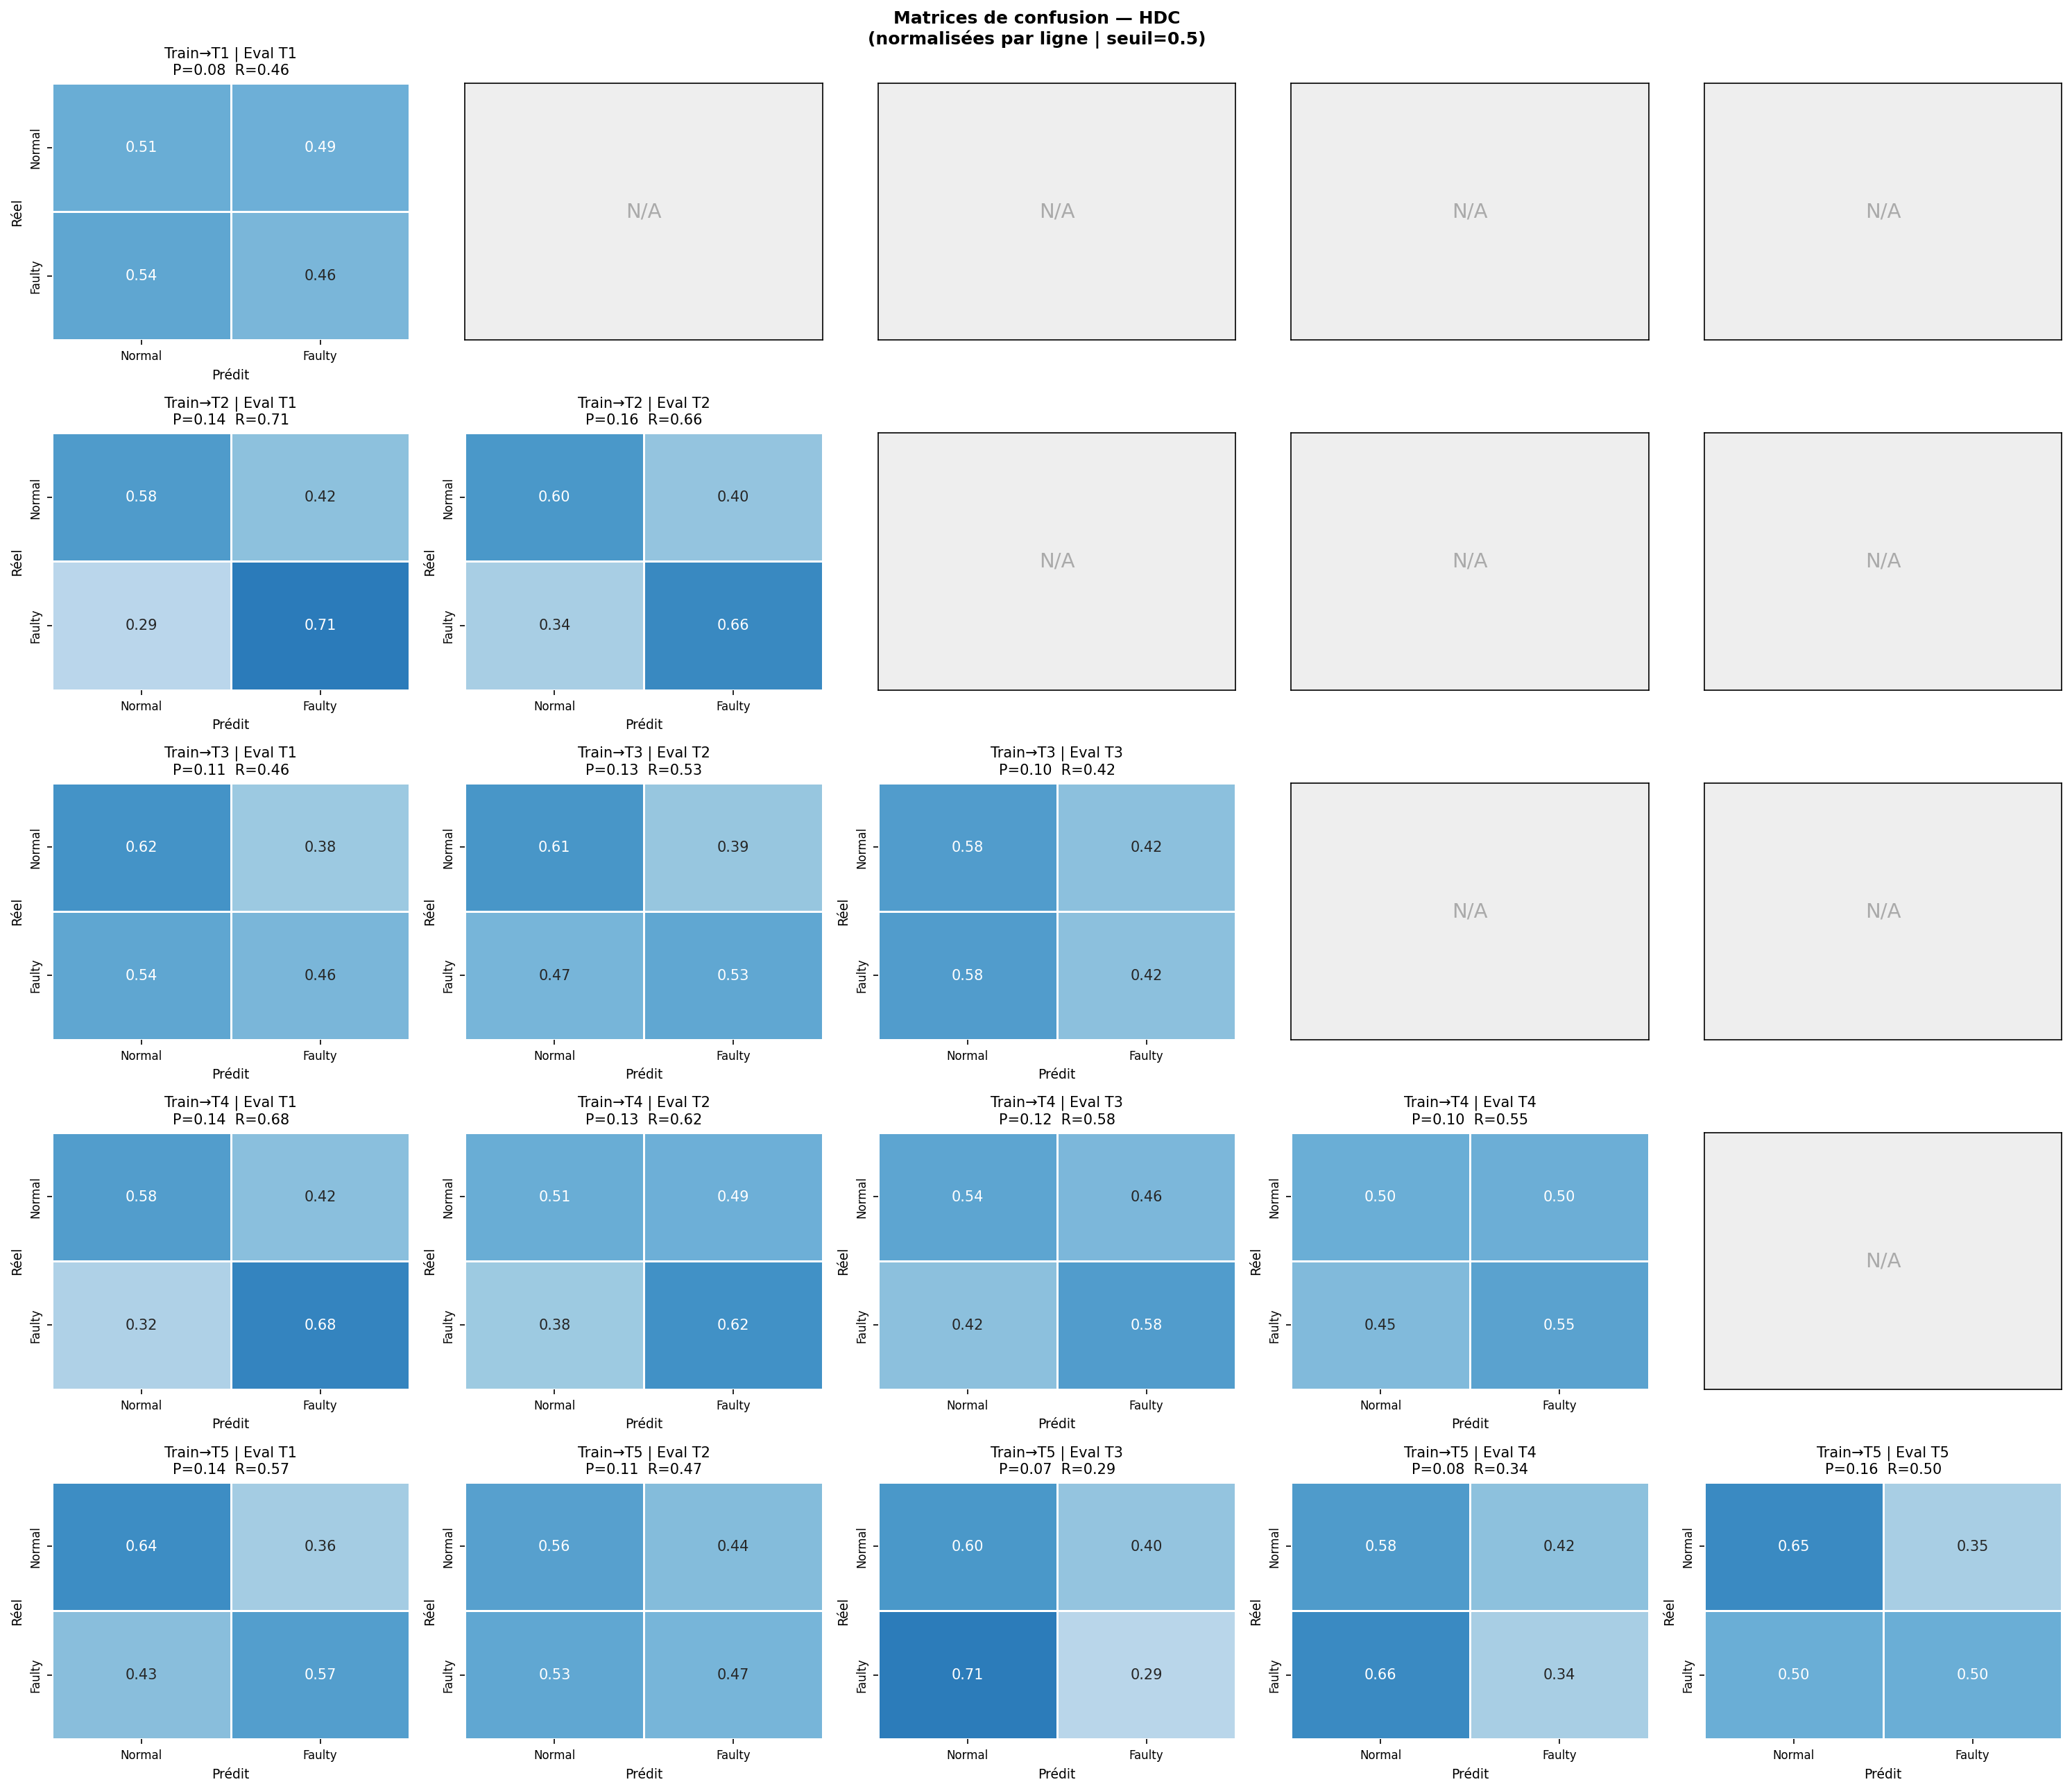

In [6]:
# Section 6 — Matrices de confusion par tâche (grille 5×5)

fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location/roc_curves.png


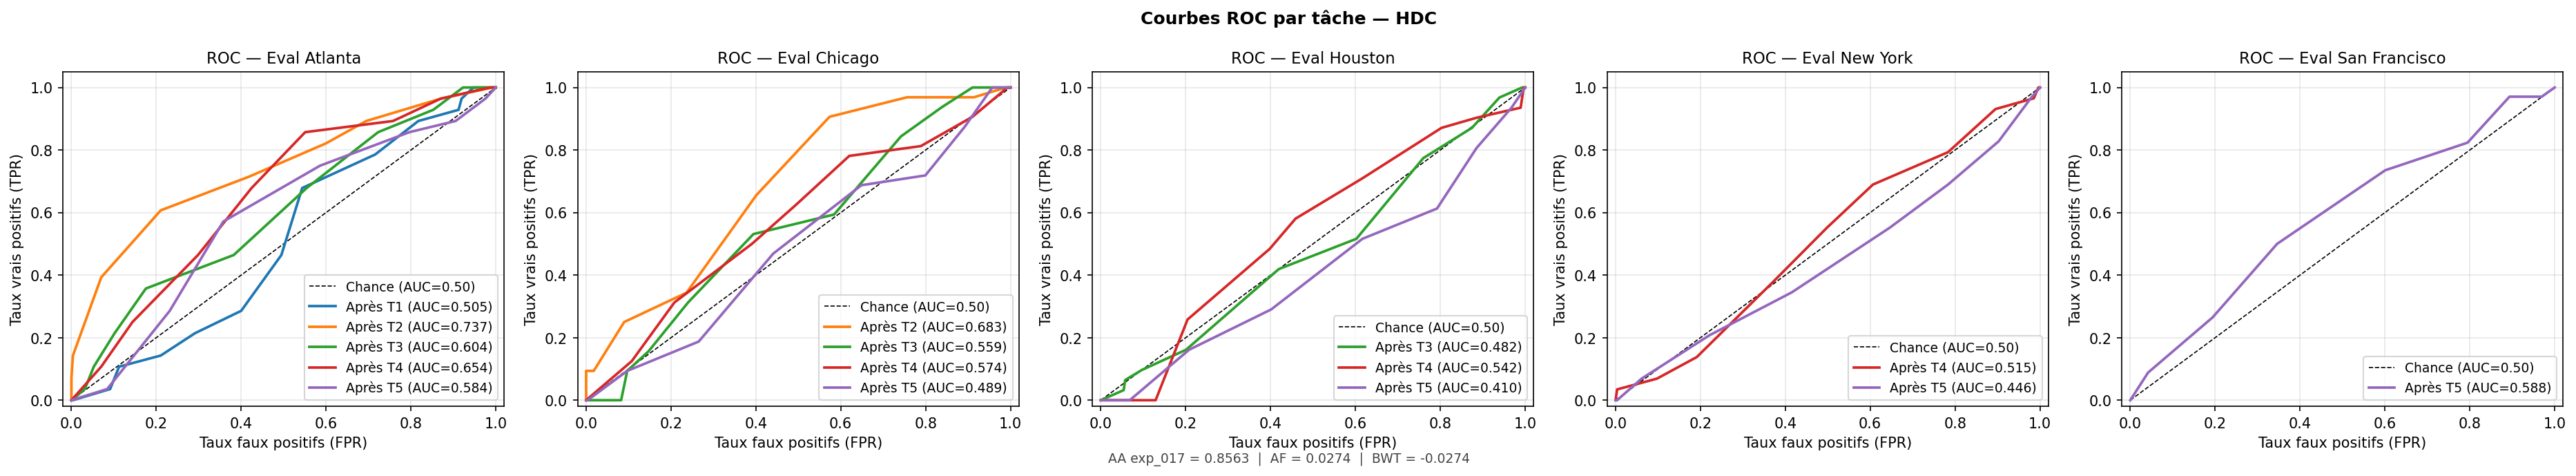

In [7]:
# Section 7 — Courbes ROC par tâche
# HDC : scores reconstruits via (sim_class1 - sim_class0) normalisés → ROC continue

fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=proba_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

fig.text(
    0.5, 0.01,
    f"AA exp_017 = {aa:.4f}  |  AF = {af:.4f}  |  BWT = {bwt:+.4f}",
    ha="center", fontsize=9, color="#444444",
)

save_figure(fig, FIGURES_DIR / "roc_curves.png")
display(Image(str(FIGURES_DIR / "roc_curves.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/hdc/monitoring/by_location/feature_space_pca.png


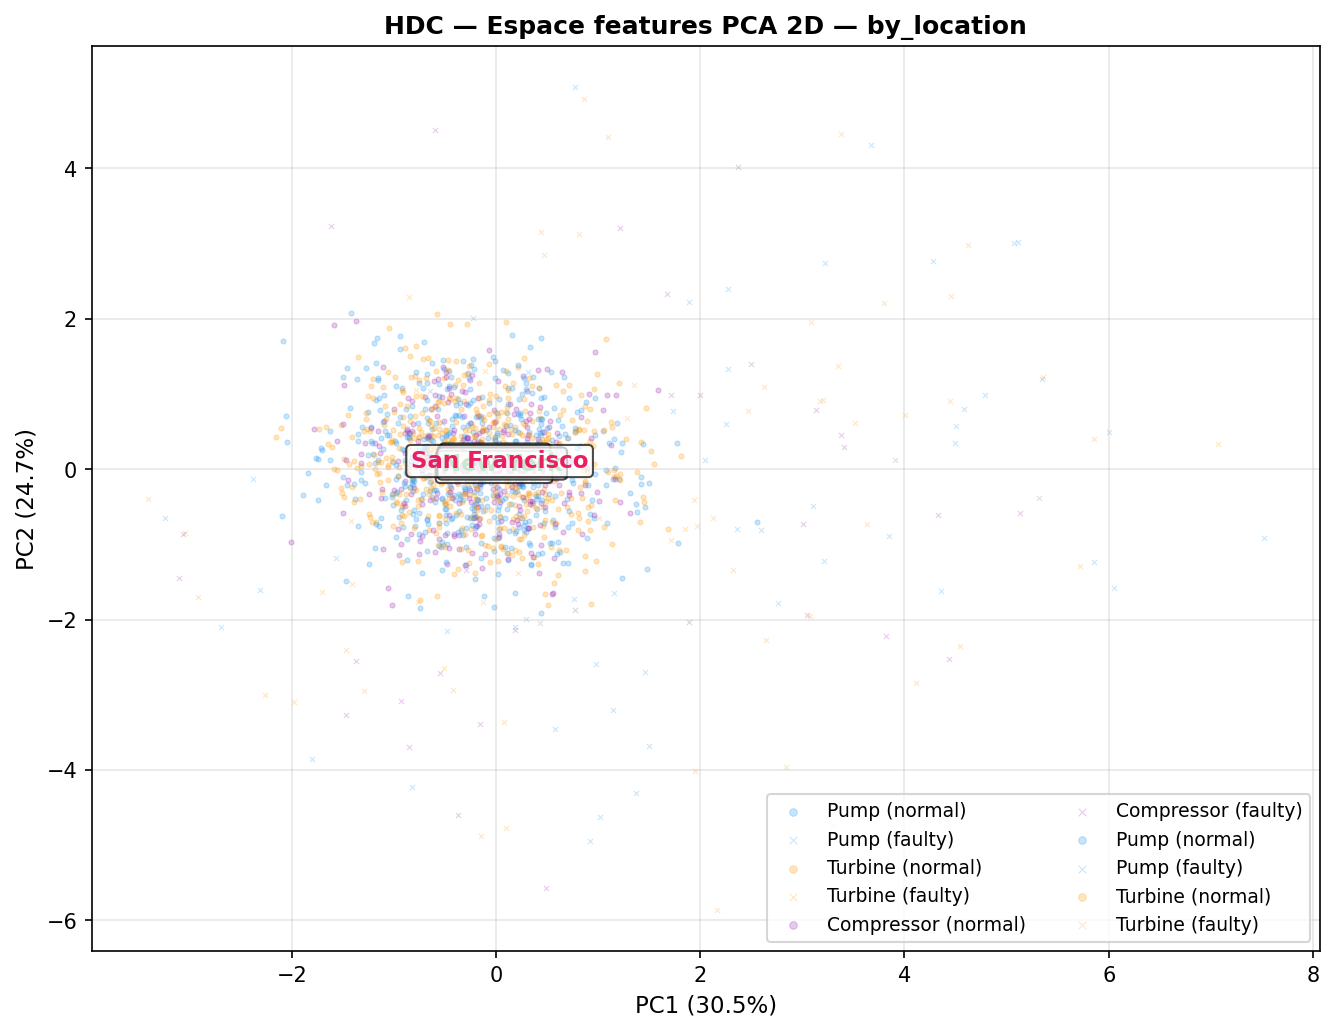

In [8]:
# Section 8 — Espace des features (PCA 2D)

if DATA_AVAILABLE and len(X_tests_raw) == len(TASK_NAMES):
    X_all      = np.concatenate(X_tests_raw, axis=0)
    y_all      = np.concatenate(y_tests_raw, axis=0)
    domain_ids = np.concatenate([
        np.full(len(X_tests_raw[k]), k) for k in range(len(TASK_NAMES))
    ])

    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_location",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50", "#E91E63"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=11,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown("> ⚠️ **Section 8 ignorée** — données non disponibles."))
    print("[SKIP] feature_space_pca.png")

In [9]:
# Section 9 — Tableau récapitulatif + critères d'acceptation

ram_ko = ram_b / 1024

display(Markdown("### Résultats finaux — HDC — monitoring/by_location (exp_017)"))

recap_table = f'''
| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_params} |
'''
display(Markdown(recap_table))

print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
if ram_int8:
    print(f"  RAM INT8 binarisé : {ram_int8/1024:.2f} Ko (Gap 3 — quantification INT8 post-training)")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 3 (architecture-based, pas de replay)")
print("=" * 60)
print(f"  Prototypes additifs (INT32 accumulateur + INT8 binarisé)")
print(f"  Aucun gradient, aucun optimiseur — conforme MCU strict")
print(f"  Les hypervecteurs sont accumulés ; l'oubli provient du shift de frontière, pas d'écrasement.")
print()
print(f"  FIXME(gap1) : HDC by_location AA=0.8563 < by_equipment AA=0.8698 —")
print(f"                le drift géographique dégrade plus fortement HDC que les autres modèles.")
print(f"                Comparaison fine dans S7-14 (notebook comparison by_location).")
print(f"  TODO(dorra) : La dimension D=1024 est-elle optimale pour 5 locations ?")
print(f"                Tester D=2048 pour voir si la capacité additionnelle réduit l'AF.")
print()

# Vérification des critères d'acceptation (S7-09)
print("=" * 60)
print("  Critères d'acceptation (S7-09)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "roc_curves.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.8563) < 0.01 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.8563)")
print(f"  [{'OK' if abs(af - 0.0274) < 0.01 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0274)")
print(f"  [{'OK' if abs(bwt + 0.0274) < 0.01 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ -0.0274)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — HDC — monitoring/by_location (exp_017)


| Modèle | AA ↑ | AF ↓ | BWT | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|-------|-----------|----------|
| HDC | 0.8563 | 0.0274 | -0.0274 | 14.16 Ko | 0.05008 ms | 2048 |


  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 14504 B = 14.16 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 51032 B (49.8 Ko)
  RAM INT8 binarisé : 6.01 Ko (Gap 3 — quantification INT8 post-training)

  NOTE SCIENTIFIQUE — Gap 3 (architecture-based, pas de replay)
  Prototypes additifs (INT32 accumulateur + INT8 binarisé)
  Aucun gradient, aucun optimiseur — conforme MCU strict
  Les hypervecteurs sont accumulés ; l'oubli provient du shift de frontière, pas d'écrasement.

  FIXME(gap1) : HDC by_location AA=0.8563 < by_equipment AA=0.8698 —
                le drift géographique dégrade plus fortement HDC que les autres modèles.
                Comparaison fine dans S7-14 (notebook comparison by_location).
  TODO(dorra) : La dimension D=1024 est-elle optimale pour 5 locations ?
                Tester D=2048 pour voir si la capacité additionnelle réduit l'AF.

  Critères d'acceptation (S7-09)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confu